<a href="https://colab.research.google.com/github/ManoloVM21/MachineLearningTeam4/blob/main/notebooks/starter_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from xgboost import XGBRegressor


In [97]:

# =========================
# Load Data
# =========================
housing = pd.read_csv(
  "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing.csv"
)

incomes_df = pd.read_csv("transposed_income_by_zip.csv")

# --- Add 'selled_again' feature ---
id_counts = housing['id'].value_counts()
housing['selled_again'] = housing['id'].map(id_counts).apply(lambda x: 1 if x > 1 else 0)
# ----------------------------------

#housing = housing[housing['sqft_living'] < 12000]
#housing = housing[housing['sqft_lot'] < 600000]
housing = housing[housing['bathrooms'] < 3]
housing = housing.drop_duplicates(subset=['id'])
#housing = housing[housing['sqft_basement'] < 2000]
#housing = housing[housing['condition'] > 2]

# --- Remove price outliers based on 2 standard deviations ---
mean_price = housing['price'].mean()
std_price = housing['price'].std()
upper_bound = mean_price + 2 * std_price
lower_bound = mean_price - 2 * std_price
housing = housing[(housing['price'] >= lower_bound) & (housing['price'] <= upper_bound)]
# ------------------------------------------------------------

seattle_offices = [
    {
        "name": "Amazon HQ - Doppler Building",
        "company": "Amazon",
        "latitude": 47.615257,
        "longitude": -122.338356
    },
    {
        "name": "Starbucks Headquarters",
        "company": "Starbucks",
        "latitude": 47.618064,
        "longitude": -122.303796
    },
    {
        "name": "Microsoft Headquarters",
        "company": "Microsoft",
        "latitude": 47.643543,
        "longitude": -122.130821
    },
    {
        "name": "Google Seattle Campus (South Lake Union)",
        "company": "Google",
        "latitude": 47.622900,
        "longitude": -122.336600
    },
    {
        "name": "Meta (Facebook) Seattle Office",
        "company": "Meta",
        "latitude": 47.623500,
        "longitude": -122.336500
    },
    {
        "name": "Zillow Headquarters",
        "company": "Zillow",
        "latitude": 47.620500,
        "longitude": -122.338000
    },
    {
        "name": "Expedia Group Headquarters (Bellevue)",
        "company": "Expedia",
        "latitude": 47.610100,
        "longitude": -122.201500
    }
]
from geopy.distance import great_circle

def calculate_distance(point1_lat, point1_long, point2_lat, point2_long):
    """Calculates the Haversine (great_circle) distance between two points."""
    point1 = (point1_lat, point1_long)
    point2 = (point2_lat, point2_long)
    return great_circle(point1, point2).km
for office in seattle_offices:
    company_name = office['company']
    office_lat = office['latitude']
    office_long = office['longitude']

    # Create a new column for the distance to this company
    housing[f'distance_to_{company_name}'] = housing.apply(
        lambda row: calculate_distance(row['lat'], row['long'], office_lat, office_long),
        axis=1
    )
seattle_water_bodies = [
    {
        "name": "Lake Union",
        "latitude": 47.6401,
        "longitude": -122.3366
    },
    {
        "name": "Lake Washington",
        "latitude": 47.6099,
        "longitude": -122.2155
    },
    {
        "name": "Puget Sound",
        "latitude": 47.6062,
        "longitude": -122.6035
    },
    {
        "name": "Green Lake",
        "latitude": 47.6749,
        "longitude": -122.3364
    },
    {
        "name": "Mercer Slough",
        "latitude": 47.5750,
        "longitude": -122.1950
    },
    {
        "name": "Elliott Bay",
        "latitude": 47.6111,
        "longitude": -122.3450
    }
]
min_distances_to_water = []

for index, row in housing.iterrows():
    house_lat = row['lat']
    house_long = row['long']

    distances_to_all_water_bodies = []
    for water_body in seattle_water_bodies:
        water_lat = water_body['latitude']
        water_long = water_body['longitude']
        distance = calculate_distance(house_lat, house_long, water_lat, water_long)
        distances_to_all_water_bodies.append(distance)

    min_distances_to_water.append(min(distances_to_all_water_bodies))

housing['distance_to_water'] = min_distances_to_water

X = housing.drop(columns=["price"])
y = housing["price"]


In [98]:
# =========================
# Custom Transformer
# =========================
class HousingFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, income_df):
        self.income_df = income_df

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # Convert 'date' to datetime and extract features
        df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
        df['sale_year'] = df['date'].dt.year
        df['sale_month'] = df['date'].dt.month
        df['house_age_at_sale'] = df['sale_year'] - df['yr_built']

        # Merge income data
        df = pd.merge(
            df,
            self.income_df[['zipcode', 'number_of_houses', 'mean_income']],
            on='zipcode',
            how='left'
        )

        # Drop unused columns
        df = df.drop(columns=[
            "id",'date' # 'id' and 'date' are now explicitly dropped after processing
        ])
        # 'zipcode' is no longer one-hot encoded here; it will be handled by ColumnTransformer
        return df


In [99]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [100]:
# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [101]:
# =========================
# Define preprocessing steps with ColumnTransformer
# =========================
from sklearn.impute import SimpleImputer # Added import for SimpleImputer

# Apply the custom feature engineer first to get the final features list
# This temporary transformation helps identify features for ColumnTransformer
feature_engineer_temp = HousingFeatureEngineer(incomes_df)
X_train_transformed_temp = feature_engineer_temp.fit_transform(X_train)

# Identify numerical and categorical columns for ColumnTransformer
# 'zipcode' is now an integer, so it's a numerical column that needs one-hot encoding.
# All other columns are numerical and need scaling.

numerical_features = X_train_transformed_temp.select_dtypes(include=np.number).columns.tolist()
categorical_features = ['zipcode'] # Explicitly handle zipcode as categorical for OHE

# Remove 'zipcode' from numerical_features if it was included
if 'zipcode' in numerical_features:
    numerical_features.remove('zipcode')

# Create a pipeline for numerical features including imputation and scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Impute NaN values (introduced by pd.to_numeric errors='coerce')
    ('scaler', StandardScaler())
])

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features), # Use the numerical_transformer pipeline
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) as they are
)


In [102]:
# =========================
# Pipeline
# =========================
pipeline = Pipeline(steps=[
    ("feature_engineering", HousingFeatureEngineer(incomes_df)), # Custom feature engineering
    ('preprocessor', preprocessor), # Scaling and One-Hot Encoding
    ("model", XGBRegressor(
        n_estimators=5000,
        learning_rate=0.02,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [103]:

# =========================
# Train
# =========================
pipeline.fit(X_train, y_train)


Pipeline(steps=[('feature_engineering',
                 HousingFeatureEngineer(income_df=    zipcode  number_of_houses  mean_income
0     98001             11109        85389
1     98002             12687        54713
2     98003             17791        61010
3     98004             15518       148860
4     98005              7507       128845
..      ...               ...          ...
65    98177              7797       124737
66    98178              8922        74831
67    98188              9610        57503
68    98198             13126        70268
69    98199              9173       126065

[70 rows x 3 columns])),
                ('preprocessor',
                 ColumnTransformer(remainder='pass...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.02,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=5000, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [104]:
# =========================
# Evaluate
# =========================
y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


RMSE: 59788.3371
R²: 0.8913


In [105]:
# =========================
# Feature Importances
# =========================
model = pipeline.named_steps["model"]

# Get feature names after preprocessing
# First, get feature names from the numerical transformer
num_feature_names = numerical_features

# Then, get feature names from the one-hot encoder
cat_feature_names = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine all feature names
processed_feature_names = list(num_feature_names) + list(cat_feature_names)

importance_df = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Feature Importances:")
print(importance_df.head(10))


Top 10 Feature Importances:
                  Feature  Importance
30            mean_income    0.124384
13                    lat    0.108710
8                   grade    0.094611
2             sqft_living    0.063443
6                    view    0.033924
25      distance_to_water    0.032560
5              waterfront    0.030518
33          zipcode_98004    0.028322
22       distance_to_Meta    0.022247
20  distance_to_Microsoft    0.021876


In [106]:
holdout_mini = pd.read_csv(
    "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing_holdout_test.csv"
)

holdout_mini.head()


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2591820310,20141006T000000,4,2.25,2070,8893,2.0,0,0,4,8,2070,0,1986,0,98058,47.4388,-122.162,2390,7700
1,7974200820,20140821T000000,5,3.00,2900,6730,1.0,0,0,5,8,1830,1070,1977,0,98115,47.6784,-122.285,2370,6283
2,7701450110,20140815T000000,4,2.50,3770,10893,2.0,0,2,3,11,3770,0,1997,0,98006,47.5646,-122.129,3710,9685
3,9522300010,20150331T000000,3,3.50,4560,14608,2.0,0,2,3,12,4560,0,1990,0,98034,47.6995,-122.228,4050,14226
4,9510861140,20140714T000000,3,2.50,2550,5376,2.0,0,0,3,9,2550,0,2004,0,98052,47.6647,-122.083,2250,4050


In [107]:
import pandas as pd
from geopy.distance import great_circle

# --- Load holdout ---
holdout_mini = pd.read_csv(
    "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing_holdout_test.csv"
)

# --- Add selled_again (same logic you used on training) ---
id_counts_holdout = holdout_mini["id"].value_counts()
holdout_mini["selled_again"] = holdout_mini["id"].map(id_counts_holdout).apply(lambda x: 1 if x > 1 else 0)

# --- Same office list you used in training ---
seattle_offices = [
    {"company": "Amazon",    "latitude": 47.615257, "longitude": -122.338356},
    {"company": "Starbucks", "latitude": 47.618064, "longitude": -122.303796},
    {"company": "Microsoft", "latitude": 47.643543, "longitude": -122.130821},
    {"company": "Google",    "latitude": 47.622900, "longitude": -122.336600},
    {"company": "Meta",      "latitude": 47.623500, "longitude": -122.336500},
    {"company": "Zillow",    "latitude": 47.620500, "longitude": -122.338000},
    {"company": "Expedia",   "latitude": 47.610100, "longitude": -122.201500},
]

def dist_km(lat1, lon1, lat2, lon2):
    return great_circle((lat1, lon1), (lat2, lon2)).km

# --- Add distance-to-office features ---
for office in seattle_offices:
    company = office["company"]
    lat2, lon2 = office["latitude"], office["longitude"]
    holdout_mini[f"distance_to_{company}"] = holdout_mini.apply(
        lambda row: dist_km(row["lat"], row["long"], lat2, lon2),
        axis=1
    )

# --- Same water bodies list you used in training ---
seattle_water_bodies = [
    {"name": "Lake Union",     "latitude": 47.6401, "longitude": -122.3366},
    {"name": "Lake Washington","latitude": 47.6099, "longitude": -122.2155},
    {"name": "Puget Sound",    "latitude": 47.6062, "longitude": -122.6035},
    {"name": "Green Lake",     "latitude": 47.6749, "longitude": -122.3364},
    {"name": "Mercer Slough",  "latitude": 47.5750, "longitude": -122.1950},
    {"name": "Elliott Bay",    "latitude": 47.6111, "longitude": -122.3450},
]

# --- Add distance_to_water (min distance to any water body) ---
holdout_mini["distance_to_water"] = holdout_mini.apply(
    lambda row: min(
        dist_km(row["lat"], row["long"], wb["latitude"], wb["longitude"])
        for wb in seattle_water_bodies
    ),
    axis=1
)


In [108]:
holdout_preds = pipeline.predict(holdout_mini)


In [109]:
submission = pd.DataFrame({
    "price": holdout_preds
})


In [110]:
submission.to_csv("team4-module3-predictions.csv", index=False)


Full Metric Set

In [111]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")


RMSE: $59,788.34
MAE:  $42,280.09
R²:   0.8913
MAPE: 10.59%


Bias Check

In [112]:
residuals = y_test - y_pred

print(f"Mean Residual (Bias): {residuals.mean():,.2f}")
print(f"Median Residual:      {np.median(residuals):,.2f}")


Mean Residual (Bias): -1,532.12
Median Residual:      -610.83


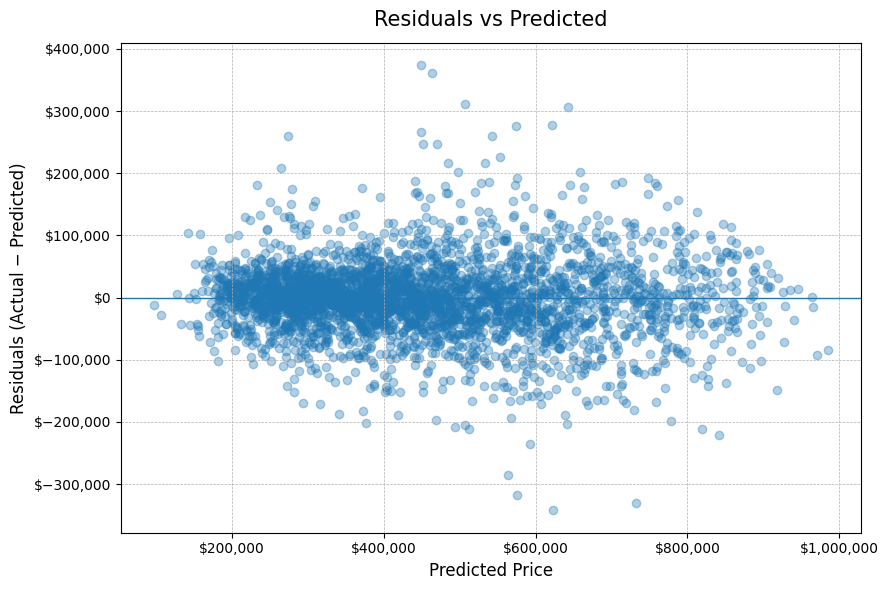

In [113]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(9, 6))

plt.scatter(y_pred, residuals, alpha=0.35)
plt.axhline(0, linewidth=1)

plt.xlabel("Predicted Price", fontsize=12)
plt.ylabel("Residuals (Actual − Predicted)", fontsize=12)
plt.title("Residuals vs Predicted", fontsize=15, pad=12)

plt.grid(True, linestyle="--", linewidth=0.5)

# Format axes as currency
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()



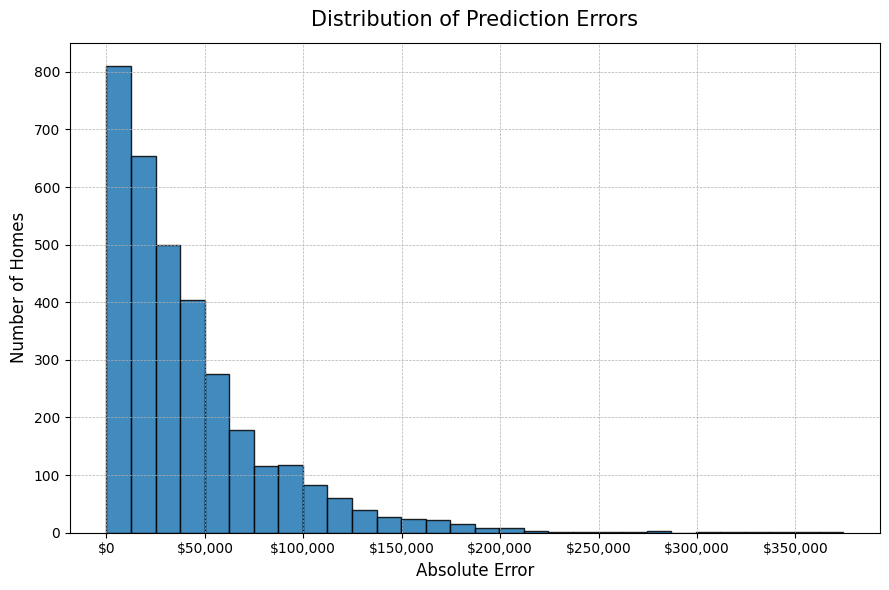

In [114]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

abs_errors = np.abs(residuals)

plt.figure(figsize=(9, 6))

plt.hist(abs_errors, bins=30, alpha=0.85, edgecolor="black")

plt.xlabel("Absolute Error", fontsize=12)
plt.ylabel("Number of Homes", fontsize=12)
plt.title("Distribution of Prediction Errors", fontsize=15, pad=12)

plt.grid(True, linestyle="--", linewidth=0.5)

# Format x-axis as currency
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()



In [115]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results["AbsError"] = np.abs(results["Actual"] - results["Predicted"])
results["PctError"] = results["AbsError"] / results["Actual"] * 100

results["Tier"] = pd.qcut(
    results["Actual"],
    q=4,
    labels=["Low", "Mid", "High", "Luxury"]
)

tier_metrics = results.groupby("Tier").agg({
    "AbsError": ["mean", "median"],
    "PctError": "mean",
    "Actual": "count"
})

print(tier_metrics)


            AbsError                PctError Actual
                mean       median       mean  count
Tier                                               
Low     35480.030869  23304.53125  16.122231    841
Mid     33963.554779  24621.90625   9.299649    850
High    43201.968037  33127.28125   8.894147    833
Luxury  56589.584487  42425.15625   8.051642    840


/tmp/ipython-input-677527438.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_metrics = results.groupby("Tier").agg({


In [116]:
property_type_features = importance_df[
    importance_df["Feature"].str.contains(
        "waterfront|view|condition|grade|floors",
        case=False
    )
]

property_type_features.sort_values(by="Importance", ascending=False)


,Feature,Importance
8,grade,0.094611
6,view,0.033924
5,waterfront,0.030518
7,condition,0.010377
4,floors,0.003143


In [117]:
results["waterfront"] = X_test["waterfront"].values

waterfront_summary = results.groupby("waterfront").agg({
    "Predicted": "mean"
})

print(waterfront_summary)


             Predicted
waterfront            
0           450217.625
1           563404.125



GRADE — mean predicted price + premium (baseline = 4)
 grade MeanPredicted Premium_vs_Baseline
     4      $216,972                  $0
     5      $252,085             $35,112
     6      $296,366             $79,394
     7      $401,310            $184,338
     8      $506,523            $289,551
     9      $629,917            $412,945
    10      $752,605            $535,633
    11      $913,434            $696,462


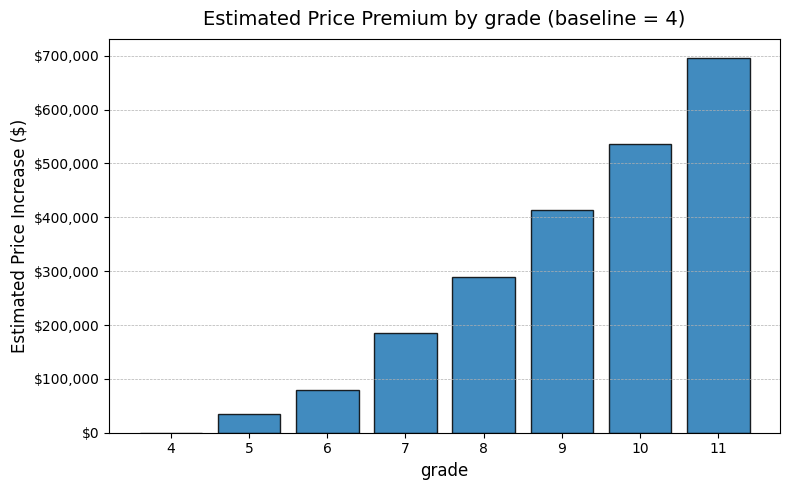


VIEW — mean predicted price + premium (baseline = 0)
 view MeanPredicted Premium_vs_Baseline
    0      $440,923                  $0
    1      $560,476            $119,553
    2      $554,398            $113,475
    3      $592,994            $152,071
    4      $650,295            $209,372


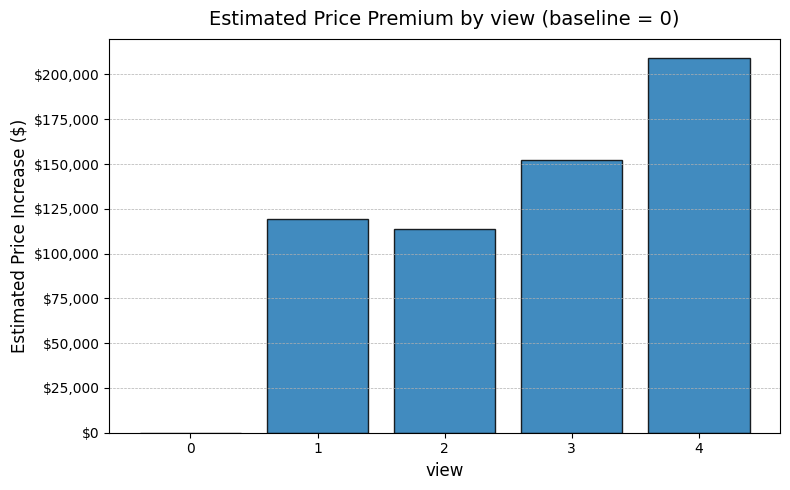


CONDITION — mean predicted price + premium (baseline = 2)
 condition MeanPredicted Premium_vs_Baseline
         1      $324,598              $6,054
         2      $318,543                  $0
         3      $448,675            $130,132
         4      $453,263            $134,720
         5      $480,781            $162,238


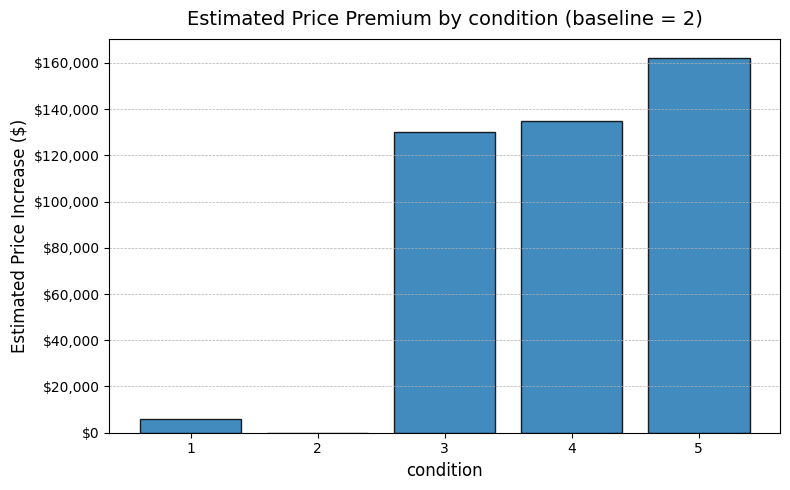


FLOORS — mean predicted price + premium (baseline = 1.0)
 floors MeanPredicted Premium_vs_Baseline
    1.0      $408,871                  $0
    1.5      $501,352             $92,481
    2.0      $497,238             $88,367
    2.5      $570,519            $161,648
    3.0      $475,890             $67,019


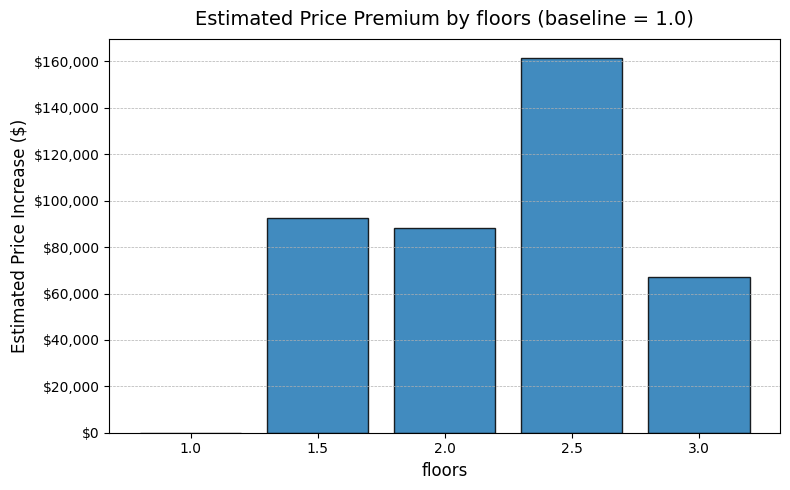


WATERFRONT — mean predicted price + premium (baseline = 0)
 waterfront MeanPredicted Premium_vs_Baseline
          0      $450,218                  $0
          1      $563,404            $113,186


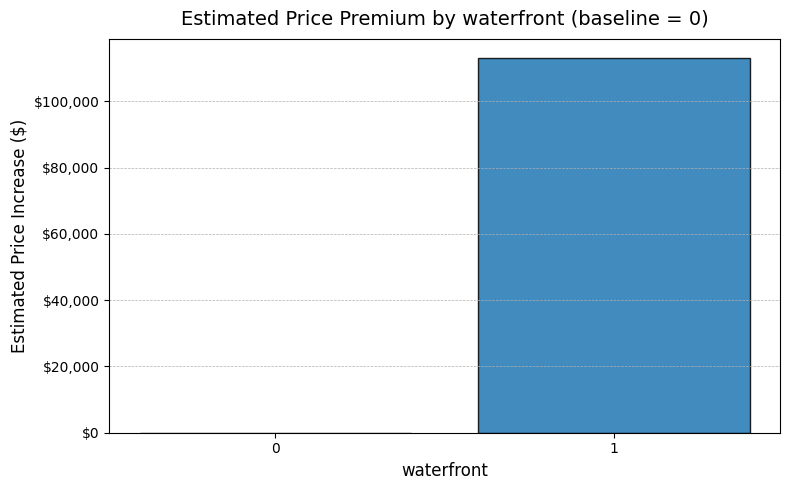

(   waterfront  MeanPredicted  Premium_vs_Baseline
 0           0     450217.625                  0.0
 1           1     563404.125             113186.5,
 waterfront
 0    450217.625
 1    563404.125
 Name: Predicted, dtype: float32,
 waterfront
 0         0.0
 1    113186.5
 Name: Predicted, dtype: float32)

In [118]:
# === Model-implied price increases (premiums) for property-type features ===
# Assumes you already have: pipeline, X_test, y_test, y_pred, residuals (optional)
# This builds a results df, computes mean predicted price by category/value,
# converts to $ premium vs baseline, prints clean tables, and plots premiums.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ---------- Build results dataframe ----------
results = pd.DataFrame({
    "Actual": y_test.values if hasattr(y_test, "values") else np.array(y_test),
    "Predicted": y_pred
})

# ---------- Helper: compute premium table + plot ----------
def premium_table_and_plot(feature, baseline="min"):
    """
    baseline:
      - "min": baseline is the lowest mean predicted group
      - "zero": baseline is group 0 (useful for binary 0/1 like waterfront)
      - numeric value: baseline is that group label (e.g., baseline=7 for grade 7)
    """
    # attach feature values from X_test
    results[feature] = X_test[feature].values

    # mean predicted by feature level
    means = results.groupby(feature)["Predicted"].mean().sort_index()

    # choose baseline
    if baseline == "min":
        base_val = means.min()
        base_label = means.idxmin()
    elif baseline == "zero":
        base_val = means.loc[0]
        base_label = 0
    else:
        base_val = means.loc[baseline]
        base_label = baseline

    premium = (means - base_val).sort_index()

    # print table
    out = pd.DataFrame({
        feature: premium.index,
        "MeanPredicted": means.values,
        "Premium_vs_Baseline": premium.values
    })
    print("\n" + "="*70)
    print(f"{feature.upper()} — mean predicted price + premium (baseline = {base_label})")
    print(out.to_string(index=False, formatters={
        "MeanPredicted": lambda x: f"${x:,.0f}",
        "Premium_vs_Baseline": lambda x: f"${x:,.0f}"
    }))

    # plot premium
    plt.figure(figsize=(8, 5))
    plt.bar(out[feature].astype(str), out["Premium_vs_Baseline"], alpha=0.85, edgecolor="black")
    plt.title(f"Estimated Price Premium by {feature} (baseline = {base_label})", fontsize=14, pad=10)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Estimated Price Increase ($)", fontsize=12)
    plt.grid(True, linestyle="--", linewidth=0.5, axis="y")
    plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    plt.tight_layout()
    plt.show()

    return out, means, premium

# ---------- Run for your property-type features ----------
# Grade / View / Condition / Floors: baseline = lowest mean predicted group
premium_table_and_plot("grade", baseline="min")
premium_table_and_plot("view", baseline="min")
premium_table_and_plot("condition", baseline="min")
premium_table_and_plot("floors", baseline="min")

# Waterfront is typically binary 0/1, so use baseline=0 (non-waterfront)
premium_table_and_plot("waterfront", baseline="zero")


In [119]:
import pandas as pd
import numpy as np

summary = []

def compute_premium(feature, baseline_type="min"):
    values = X_test[feature].values
    temp = pd.DataFrame({
        feature: values,
        "Predicted": y_pred
    })

    means = temp.groupby(feature)["Predicted"].mean()

    if baseline_type == "min":
        baseline_val = means.min()
        baseline_label = means.idxmin()
    elif baseline_type == "zero":
        baseline_val = means.loc[0]
        baseline_label = 0
    else:
        baseline_val = means.loc[baseline_type]
        baseline_label = baseline_type

    max_val = means.max()
    max_label = means.idxmax()

    premium = max_val - baseline_val

    summary.append({
        "Feature": feature,
        "Baseline": baseline_label,
        "Highest_Level": max_label,
        "Estimated_Premium": premium
    })

# Property-type features
compute_premium("grade", baseline_type="min")
compute_premium("view", baseline_type="min")
compute_premium("condition", baseline_type="min")
compute_premium("floors", baseline_type="min")
compute_premium("waterfront", baseline_type="zero")

premium_table = pd.DataFrame(summary)

premium_table["Estimated_Premium"] = premium_table["Estimated_Premium"].map(lambda x: f"${x:,.0f}")

premium_table


,Feature,Baseline,Highest_Level,Estimated_Premium
0,grade,4.0,11.0,"$696,462"
1,view,0.0,4.0,"$209,372"
2,condition,2.0,5.0,"$162,238"
3,floors,1.0,2.5,"$161,648"
4,waterfront,0.0,1.0,"$113,186"
